# EDA

In [1]:
# EDA methodology adapted from
# https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Lucky number
random_state = 8

In [3]:
# Loading dataset
dataset = pd.read_csv('../../../data/processed/cs199_data.csv')
dataset.head()

,SAMPLEID,6_ANSWERDATE,6_SEX,6_AGE,6_AGEID,6_PREFECTURE,6_AREA,6_MARRIED,6_CHILD,6_HINCOME,...,6_Mental_group,6_Covid_group,6_K6_group3,6_K6_group2,6_PHQ9_%,6_GAD_%,6_PHQ9_item9,6_PHQ9_SI,6_LSNS_group,6_AUDIT_group
0,1106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1916,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3793,5-13-2024,1.0,57.0,10.0,40.0,8.0,2.0,2.0,4.0,...,4.0,4.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0


In [4]:
# Sorting dataset based on SAMPLEID
dataset_sorted = dataset.sort_values(by=['SAMPLEID'])

In [5]:
dataset_sorted.head()

,SAMPLEID,6_ANSWERDATE,6_SEX,6_AGE,6_AGEID,6_PREFECTURE,6_AREA,6_MARRIED,6_CHILD,6_HINCOME,...,6_Mental_group,6_Covid_group,6_K6_group3,6_K6_group2,6_PHQ9_%,6_GAD_%,6_PHQ9_item9,6_PHQ9_SI,6_LSNS_group,6_AUDIT_group
0,1106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16161,1171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16162,1263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14191,1346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18612,1398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Setting attributes
dataset_cleaned = dataset_sorted[[
 #'SAMPLEID',
 #'6_ANSWERDATE',
 '6_SEX', #"1 Male 2 Female"
 '6_AGE',
 #'6_AGEID',
 #'6_PREFECTURE',
 #'6_AREA',
 '6_MARRIED', #"1 unmarried 2 married"
 '6_CHILD', #"1 no children 2 with children"
 '6_HINCOME',
 '6_PINCOME', #same coding as HINCOME
 '6_JOB',
 #'6_STUDENT',
 '6_Number_fam', #Please indicate by number how many people (not including yourself) live with you.
 #'6_SchoolGrade',
 #'6_YearsEnrolled',
 '6_VacNum', #Number of vaccinations

 '6_Med_self', # "I am a healthcare professional (doctor, nurse, other healthcare professional, pharmacist, caregiver, etc.) 1 yes 2 no"
 '6_Medself_covid', # "As a medical worker, I am dealing with new corona patients. 1 yes 2 no"
 '6_Med_fam', #"Have a family member who is a healthcare worker 1 yes 2 no"
 '6_Medfam_covid', #"There is a person in the family who is dealing with new corona patients as a medical worker. 　1 yes 2 no"
 '6_Current_physical', #Whether the respondent has been treated for a physical illness in the past
 '6_Past_physical', #Whether the respondent is currently being treated for a mental disorder
 '6_Current_mental', #Whether the respondent has been treated for mental illness in the past
 '6_Past_mental', #Currently being treated for COVID-19
 '6_Current_covid19', #"Currently undergoing treatment for COVID-19. 1 yes 2 no"
 '6_Past_covid19', #"Have received treatment for COVID-19 in the past. 1 yes 2 no"

 '6_Exercise',
 '6_HealthyDiet',
 '6_FavoriteActivity',
 '6_Interaction_offline',
 '6_Interaction_online',

 '6_PB_Continuous', #We continued to take preventive actions against the new coronavirus infection (wearing a mask, washing hands, limiting going out, etc.).
 '6_PB_Altruistic', #Voluntarily took preventive actions (wearing a mask, washing hands, limiting going out, etc.) to prevent the spread of the new coronavirus to family members and others.
 '6_PB_Avoidant', #To avoid social criticism and pressure, they took preventive actions (wearing masks, washing hands, limiting going out, etc.).
 '6_Trust_gov',
 '6_Trust_SM',
 '6_Vaccination_will',
 '6_PB_understanding',
 '6_Optimism',
 '6_HealthySleep',
 '6_DeteriorationEconomy',
 '6_DeteriorationInteract',
 '6_Frustration',
 '6_CovidAnxiety',
 '6_CovidSleepless',
 '6_DifficultyLiving',
 '6_DifficultyWork',

 '6_PTG1_S22',
 '6_PTG2_S23',
 '6_PTG3_S24',
 '6_PTG4_S25',
 '6_PTG5_S_26',
 '6_PTG6_S27',
 '6_Social_Capital_Q8S1',
 '6_Social_Capital_Q8S2',
 '6_Social_Capital_Q8S3',
 '6_Social_Capital_Q8S4',
 '6_Social_Capital_Q8S5',
 '6_Social_Capital_Q9S1',
 '6_Social_Capital_Q9S2',
 '6_Social_Capital_Q9S3',
 '6_Social_Capital_Q10S1_1',
 '6_Social_Capital_Q10S1_2',
 '6_Social_Capital_Q10S1_3',
 '6_Social_Capital_Q10S1_4',
 '6_Social_Capital_Q10S1_5',
 '6_Social_Capital_Q10S1_6',
 '6_Social_Capital_Q10S1_7',
 '6_Social_Capital_Q10S1_8',
 '6_Social_Capital_Q10S2_1',
 '6_Social_Capital_Q10S2_2',
 '6_Social_Capital_Q10S2_3',
 '6_Social_Capital_Q10S2_4',
 '6_Social_Capital_Q10S2_5',
 '6_Social_Capital_Q10S2_6',
 '6_Social_Capital_Q10S2_7',
 '6_Social_Capital_Q10S2_8',
 '6_Social_Capital_Q10S3_1',
 '6_Social_Capital_Q10S3_2',
 '6_Social_Capital_Q10S3_3',
 '6_Social_Capital_Q10S3_4',
 '6_Social_Capital_Q10S3_5',
 '6_Social_Capital_Q10S3_6',
 '6_Social_Capital_Q10S3_7',
 '6_Social_Capital_Q10S3_8',
 '6_Social_Capital_Q10S1_7FA',
 '6_Social_Capital_Q10S2_7FA',
 '6_Social_Capital_Q10S3_7FA',
 '6_K6_total',
 '6_PHQ9_total',
 '6_GAD7_total',
 '6_SSS8_total',
 '6_PTGI-X(Q7_22_27)',
 '6_SHS_total',
 '6_UCLA_total',
 '6_LSNS6_total',
 '6_AUDIT']]

 #'6_Age_group',
 #'6_HINCOME_group',
 #'6_JOB_group',
 #'6_Med_group',
 #'6_Med_covid_group',
 #'6_Physical_group',
 #'6_Mental_group',
 #'6_Covid_group',
 #'6_K6_group3',
 #'6_K6_group2',
 #'6_PHQ9_%',
 #'6_GAD_%',
 #'6_PHQ9_item9',
 #'6_PHQ9_SI',
 #'6_LSNS_group',
 #'6_AUDIT_group']

In [7]:
dataset_cleaned

,6_SEX,6_AGE,6_MARRIED,6_CHILD,6_HINCOME,6_PINCOME,6_JOB,6_Number_fam,6_VacNum,6_Med_self,...,6_Social_Capital_Q10S3_7FA,6_K6_total,6_PHQ9_total,6_GAD7_total,6_SSS8_total,6_PTGI-X(Q7_22_27),6_SHS_total,6_UCLA_total,6_LSNS6_total,6_AUDIT
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16162,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18612,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17614,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20047,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
dataset_cleaned.shape

(24050, 90)

# Preprocessing

In [9]:
# Get initial number of rows
initial_rows = len(dataset_sorted)

# Convert all columns to numeric, forcing non-numeric values to NaN
dataset_cleaned = dataset_cleaned.apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN values (originally non-numeric values)
dataset_cleaned = dataset_cleaned.dropna()

# Get final number of rows
final_rows = len(dataset_cleaned)
row_count = len(dataset_cleaned)

# Print number of dropped rows
print(f"Number of rows dropped: {initial_rows - final_rows}")


Number of rows dropped: 21424


In [10]:
Q1 = dataset_cleaned[['6_HINCOME', '6_PINCOME']].quantile(0.25)
Q3 = dataset_cleaned[['6_HINCOME', '6_PINCOME']].quantile(0.75)
IQR = Q3 - Q1

# Filtering out outliers
dataset_cleaned = dataset_cleaned[~((dataset_cleaned[['6_HINCOME', '6_PINCOME']] < (Q1 - 1.5 * IQR)) | 
                                    (dataset_cleaned[['6_HINCOME', '6_PINCOME']] > (Q3 + 1.5 * IQR))).any(axis=1)]

new_rows = len(dataset_cleaned)
print(f"Number of rows dropped: {row_count - new_rows}")
row_count = new_rows


Number of rows dropped: 340


In [11]:
column = '6_SEX'

def sex_categories(x):
    if x == 1:
        return 'Male'
    else:
        return 'Female'


# Transform columns in categorical descriptions
dataset_cleaned[column] = dataset_cleaned[column].apply(sex_categories)

In [12]:
column = '6_MARRIED'

def married_categories(x):
    if x == 1:
        return 'Unmarried'
    else:
        return 'Married'
    
# Transform columns in categorical descriptions
dataset_cleaned[column] = dataset_cleaned[column].apply(married_categories)

In [13]:
column = '6_JOB'

def job_categories(x):
    if x == 1:
        return 'Civil Servant'
    elif x == 2:
        return 'Management and Officers'
    elif x == 3:
        return 'Company Employee (Clerical)'
    elif x == 4: 
        return 'Company Employee (Technical)'
    elif x == 5:
        return 'Company Employee (Other)'
    elif x == 6:
        return 'Self-employed'
    elif x == 7:
        return 'Freelance'
    elif x == 8:
        return 'Full-time Housewife/Househusband'
    elif x == 9:
        return 'Part-time Worker'
    elif x == 10:
        return 'Student'
    elif x == 11:
        return 'Others'
    else:
        return 'Unemployed'
    
# Transform columns in categorical descriptions
dataset_cleaned[column] = dataset_cleaned[column].apply(job_categories)

In [14]:
columns = [
 '6_Med_self', # "I am a healthcare professional (doctor, nurse, other healthcare professional, pharmacist, caregiver, etc.) 1 yes 2 no"
 '6_Medself_covid', # "As a medical worker, I am dealing with new corona patients. 1 yes 2 no"
 '6_Med_fam', #"Have a family member who is a healthcare worker 1 yes 2 no"
 '6_Medfam_covid', #"There is a person in the family who is dealing with new corona patients as a medical worker. 　1 yes 2 no"
 '6_Current_physical', #Whether the respondent has been treated for a physical illness in the past
 '6_Past_physical', #Whether the respondent is currently being treated for a mental disorder
 '6_Current_mental', #Whether the respondent has been treated for mental illness in the past
 '6_Past_mental', #Currently being treated for COVID-19
 '6_Current_covid19', #"Currently undergoing treatment for COVID-19. 1 yes 2 no"
 '6_Past_covid19' #"Have received treatment for COVID-19 in the past. 1 yes 2 no"
]
 
def yesno_categories(x):
    if x == 1:
        return 'Yes'
    else:
        return 'No'
    
# Transform columns in categorical descriptions
for column in columns:
    dataset_cleaned[column] = dataset_cleaned[column].apply(yesno_categories)

In [15]:
dataset_cleaned

,6_SEX,6_AGE,6_MARRIED,6_CHILD,6_HINCOME,6_PINCOME,6_JOB,6_Number_fam,6_VacNum,6_Med_self,...,6_Social_Capital_Q10S3_7FA,6_K6_total,6_PHQ9_total,6_GAD7_total,6_SSS8_total,6_PTGI-X(Q7_22_27),6_SHS_total,6_UCLA_total,6_LSNS6_total,6_AUDIT
4,Male,57.0,Married,2.0,4.0,3.0,Company Employee (Technical),2.0,3.0,No,...,0.0,12.0,15.0,14.0,18.0,19.0,4.00,24.0,4.0,6.0
8,Female,70.0,Married,2.0,7.0,1.0,Full-time Housewife/Househusband,3.0,3.0,No,...,0.0,1.0,0.0,0.0,1.0,3.0,4.50,11.0,18.0,0.0
11,Male,52.0,Unmarried,1.0,3.0,3.0,Company Employee (Clerical),1.0,3.0,No,...,0.0,1.0,2.0,0.0,1.0,0.0,4.00,32.0,0.0,0.0
15,Male,66.0,Married,2.0,4.0,2.0,Company Employee (Clerical),3.0,3.0,No,...,0.0,0.0,0.0,0.0,0.0,18.0,5.50,21.0,13.0,0.0
21,Male,62.0,Unmarried,2.0,3.0,3.0,Company Employee (Technical),1.0,5.0,No,...,0.0,0.0,0.0,0.0,6.0,18.0,3.75,24.0,5.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11189,Male,73.0,Married,1.0,6.0,5.0,Management and Officers,1.0,6.0,No,...,0.0,0.0,1.0,0.0,4.0,19.0,5.00,28.0,5.0,22.0
11204,Male,57.0,Married,2.0,2.0,2.0,Company Employee (Clerical),3.0,3.0,No,...,0.0,12.0,4.0,7.0,13.0,18.0,4.00,25.0,6.0,6.0
11209,Female,50.0,Married,1.0,5.0,1.0,Full-time Housewife/Househusband,1.0,5.0,No,...,0.0,13.0,6.0,0.0,5.0,12.0,3.75,26.0,4.0,0.0
11288,Female,33.0,Unmarried,1.0,4.0,4.0,Company Employee (Clerical),0.0,3.0,No,...,0.0,2.0,3.0,2.0,14.0,12.0,4.00,27.0,3.0,0.0


In [16]:
from sklearn.preprocessing import StandardScaler

# Select numerical features for standardization
numerical_features = [
 '6_HINCOME',
 '6_PINCOME', #same coding as HINCOME
 '6_VacNum', #Number of vaccinations
    
 '6_Exercise',
 '6_HealthyDiet',
 '6_FavoriteActivity',
 '6_Interaction_offline',
 '6_Interaction_online',

 '6_PB_Continuous', #We continued to take preventive actions against the new coronavirus infection (wearing a mask, washing hands, limiting going out, etc.).
 '6_PB_Altruistic', #Voluntarily took preventive actions (wearing a mask, washing hands, limiting going out, etc.) to prevent the spread of the new coronavirus to family members and others.
 '6_PB_Avoidant', #To avoid social criticism and pressure, they took preventive actions (wearing masks, washing hands, limiting going out, etc.).
 '6_Trust_gov',
 '6_Trust_SM',
 '6_Vaccination_will',
 '6_PB_understanding',
 '6_Optimism',
 '6_HealthySleep',
 '6_DeteriorationEconomy',
 '6_DeteriorationInteract',
 '6_Frustration',
 '6_CovidAnxiety',
 '6_CovidSleepless',
 '6_DifficultyLiving',
 '6_DifficultyWork',

 '6_PTG1_S22',
 '6_PTG2_S23',
 '6_PTG3_S24',
 '6_PTG4_S25',
 '6_PTG5_S_26',
 '6_PTG6_S27',
 '6_Social_Capital_Q8S1',
 '6_Social_Capital_Q8S2',
 '6_Social_Capital_Q8S3',
 '6_Social_Capital_Q8S4',
 '6_Social_Capital_Q8S5',
 '6_Social_Capital_Q9S1',
 '6_Social_Capital_Q9S2',
 '6_Social_Capital_Q9S3',
 '6_Social_Capital_Q10S1_1',
 '6_Social_Capital_Q10S1_2',
 '6_Social_Capital_Q10S1_3',
 '6_Social_Capital_Q10S1_4',
 '6_Social_Capital_Q10S1_5',
 '6_Social_Capital_Q10S1_6',
 '6_Social_Capital_Q10S1_7',
 '6_Social_Capital_Q10S1_8',
 '6_Social_Capital_Q10S2_1',
 '6_Social_Capital_Q10S2_2',
 '6_Social_Capital_Q10S2_3',
 '6_Social_Capital_Q10S2_4',
 '6_Social_Capital_Q10S2_5',
 '6_Social_Capital_Q10S2_6',
 '6_Social_Capital_Q10S2_7',
 '6_Social_Capital_Q10S2_8',
 '6_Social_Capital_Q10S3_1',
 '6_Social_Capital_Q10S3_2',
 '6_Social_Capital_Q10S3_3',
 '6_Social_Capital_Q10S3_4',
 '6_Social_Capital_Q10S3_5',
 '6_Social_Capital_Q10S3_6',
 '6_Social_Capital_Q10S3_7',
 '6_Social_Capital_Q10S3_8',
 '6_Social_Capital_Q10S1_7FA',
 '6_Social_Capital_Q10S2_7FA',
 '6_Social_Capital_Q10S3_7FA',
 '6_K6_total',
 '6_PHQ9_total',
 '6_GAD7_total',
 '6_SSS8_total',
 '6_PTGI-X(Q7_22_27)',
 '6_SHS_total',
 '6_UCLA_total',
 '6_LSNS6_total',
 '6_AUDIT'
]

scaler = StandardScaler()
dataset_cleaned[numerical_features] = scaler.fit_transform(dataset_cleaned[numerical_features])

In [17]:
categorical_columns = [
    '6_SEX',
    '6_AGE',
    '6_MARRIED',
    '6_CHILD',
    '6_JOB',
    '6_Number_fam',
    '6_Med_self',
    '6_Medself_covid',
    '6_Med_fam',
    '6_Medfam_covid',
    '6_Current_physical',
    '6_Past_physical',
    '6_Current_mental',
    '6_Past_mental',
    '6_Current_covid19',
    '6_Past_covid19'
]

dataset_cleaned = pd.get_dummies(dataset_cleaned, columns=categorical_columns, drop_first=True)

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
dataset_cleaned[numerical_features] = scaler.fit_transform(dataset_cleaned[numerical_features])

In [19]:
dataset_cleaned

,6_HINCOME,6_PINCOME,6_VacNum,6_Exercise,6_HealthyDiet,6_FavoriteActivity,6_Interaction_offline,6_Interaction_online,6_PB_Continuous,6_PB_Altruistic,...,6_Med_self_Yes,6_Medself_covid_Yes,6_Med_fam_Yes,6_Medfam_covid_Yes,6_Current_physical_Yes,6_Past_physical_Yes,6_Current_mental_Yes,6_Past_mental_Yes,6_Current_covid19_Yes,6_Past_covid19_Yes
4,0.444444,0.500000,0.272727,0.666667,0.500000,0.500000,0.500000,0.500000,0.500000,0.666667,...,False,False,False,False,False,False,False,False,False,False
8,0.777778,0.166667,0.272727,0.000000,0.833333,0.500000,0.500000,0.666667,1.000000,1.000000,...,False,False,False,False,False,False,False,False,False,False
11,0.333333,0.500000,0.272727,0.166667,0.333333,0.166667,0.000000,0.000000,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,False
15,0.444444,0.333333,0.272727,0.833333,0.666667,0.500000,0.666667,0.000000,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,False
21,0.333333,0.500000,0.454545,0.000000,0.500000,0.500000,0.000000,0.000000,1.000000,1.000000,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11189,0.666667,0.833333,0.545455,0.333333,0.666667,0.666667,0.500000,0.333333,0.166667,0.333333,...,False,False,False,False,False,False,False,False,False,False
11204,0.222222,0.333333,0.272727,0.666667,0.666667,0.500000,0.500000,0.666667,0.666667,0.666667,...,False,False,False,False,False,False,False,False,False,False
11209,0.555556,0.166667,0.454545,0.333333,0.500000,0.500000,0.333333,0.333333,0.333333,0.333333,...,False,False,False,False,False,False,False,False,False,True
11288,0.444444,0.666667,0.272727,0.666667,0.500000,0.500000,0.666667,0.500000,0.500000,0.500000,...,False,False,False,False,False,False,False,True,False,False


# Train-Test Split

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
# Extract the target and features
y = dataset_cleaned['6_UCLA_total']
X = dataset_cleaned.drop(columns=['6_UCLA_total'])

#Get the training and test set from the K6 dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 30)

# Calculate the count of each unique label
unique_labels, label_counts = np.unique(y_test, return_counts=True)

# Model Training

In [22]:
# https://www.geeksforgeeks.org/random-forest-regression-in-python/
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{model.__class__.__name__}:")
    print(f"  MAE: {mae:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  R²: {r2:.4f}")
    print("-" * 30)
    
    return r2

In [27]:
# Train Random Forest Regressor
regressor = RandomForestRegressor(random_state=random_state)
regressor.fit(X_train, y_train)
evaluate(regressor, X_test, y_test)

RandomForestRegressor:
  MAE: 0.0989
  MSE: 0.0160
  R²: 0.5721
------------------------------


0.5720750772352611

In [28]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

regressors = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=random_state),
    "Lasso Regression": Lasso(random_state=random_state),
    "Decision Tree": DecisionTreeRegressor(random_state=random_state),
    "Random Forest": RandomForestRegressor(random_state=random_state),
    "Gradient Boosting": GradientBoostingRegressor(random_state=random_state),
    "Support Vector Machine": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor()
}

# Iterate through each regressor and test it
for name, model in regressors.items():
    model.fit(X_train, y_train)
    evaluate(model, X_test, y_test)


LinearRegression:
  MAE: 0.1040
  MSE: 0.0171
  R²: 0.5411
------------------------------
Ridge:
  MAE: 0.1034
  MSE: 0.0169
  R²: 0.5476
------------------------------
Lasso:
  MAE: 0.1460
  MSE: 0.0374
  R²: -0.0022
------------------------------
DecisionTreeRegressor:
  MAE: 0.1401
  MSE: 0.0334
  R²: 0.1044
------------------------------
RandomForestRegressor:
  MAE: 0.0989
  MSE: 0.0160
  R²: 0.5721
------------------------------
GradientBoostingRegressor:
  MAE: 0.0982
  MSE: 0.0155
  R²: 0.5844
------------------------------
SVR:
  MAE: 0.1009
  MSE: 0.0162
  R²: 0.5641
------------------------------
KNeighborsRegressor:
  MAE: 0.1249
  MSE: 0.0265
  R²: 0.2904
------------------------------


# Model Tuning

In [29]:
import pprint
import joblib as job
import time

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

pp = pprint.PrettyPrinter(indent=1)

In [30]:
# Define hyperparameter space
n_estimators = [100, 250, 500, 1000]                       # Range of trees
max_features = [1, 2, 3, 4]                                # Feature selection
max_depth = [int(x) for x in np.linspace(10, 100, num=10)]
max_depth.append(None) # Depth
min_samples_split = [2, 5, 10, 15]                     # Control overfitting
min_samples_leaf = [1, 2, 4, 6]                       # Prevent overfitting
bootstrap = [True, False]                              # Sampling strategy
cv = 10                                         # Cross-validation folds

# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

print('Hyperparameter search space')
pp.pprint(random_grid)

Hyperparameter search space
{'bootstrap': [True, False],
 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
 'max_features': [1, 2, 3, 4],
 'min_samples_leaf': [1, 2, 4, 6],
 'min_samples_split': [2, 5, 10, 15],
 'n_estimators': [100, 250, 500, 1000]}


In [31]:
# Set model to RandomForestRegressor
model = RandomForestRegressor(verbose=0)

In [32]:
# Set the hyperparameter tuner
start_time = time.time()
random_tuner = RandomizedSearchCV(estimator=model, param_distributions=random_grid, n_iter=3000, cv=5, scoring='r2', 
                           random_state=random_state, verbose=1, return_train_score=True, n_jobs=10)
print('\nCross-validation via', random_tuner)

# Fit the random search model
print("Fitting the Randomized Search model...")
random_tuner.fit(X_train, y_train)
print("Randomized Search CV completed.")

# Time taken for Randomized Search
end_time = time.time()
running_time = end_time - start_time
print('\nRandom Forest training time:', running_time, 's')


Cross-validation via RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=3000,
                   n_jobs=10,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, None],
                                        'max_features': [1, 2, 3, 4],
                                        'min_samples_leaf': [1, 2, 4, 6],
                                        'min_samples_split': [2, 5, 10, 15],
                                        'n_estimators': [100, 250, 500, 1000]},
                   random_state=8, return_train_score=True, scoring='r2',
                   verbose=1)
Fitting the Randomized Search model...
Fitting 5 folds for each of 3000 candidates, totalling 15000 fits


KeyboardInterrupt: 

In [ ]:
start_time = time.time()
grid_tuner = GridSearchCV(estimator=model, param_grid=random_grid, cv=cv, scoring='r2', 
                     verbose=6, return_train_score=True, n_jobs=10)
print('\nCross-validation via', grid_tuner)

# Fit the random search model
print("Fitting the Grid Search model...")
grid_tuner.fit(X_train, y_train)
print("Grid Search CV completed.")

end_time = time.time()
running_time = end_time - start_time
print('\nRandom Forest training time:', running_time, 's')

In [54]:
# Save the model
model_name = type(grid_tuner).__name__
file_name = model_name + '_' + time.strftime("%Y%m%d-%H%M%S") + '.mod'
file_save = file_name

print('Saving', model_name, 'model as', file_name, '...')
job.dump(grid_tuner, file_save) 

Saving RandomizedSearchCV model as RandomizedSearchCV_20250225-223744.mod ...


['RandomizedSearchCV_20250225-223744.mod']

In [55]:
# Load the model
file_model = ""
file_load = file_model

saved_model = job.load(file_load) 
tuner = saved_model

print('Best hyperparameters:')
pp.pprint(tuner.best_estimator_.get_params())

Best hyperparameters:
{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 70,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 6,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 8,
 'verbose': 0,
 'warm_start': False}


{'n_estimators': [100, 250, 500, 1000], 'max_features': ['sqrt', 'log2'], 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None], 'min_samples_split': [2, 5, 10, 15], 'min_samples_leaf': [1, 2, 4, 6], 'bootstrap': [True, False], 'class_weight': ['balanced', None]}
n_estimators = 100 : -0.3576022755839897
n_estimators = 250 : -0.2936063879921204
n_estimators = 500 : -0.3447385004001174
n_estimators = 1000 : -0.3320224389158885
max_features = sqrt : -0.3067572833912081
max_features = log2 : -0.36265115625197236
max_depth = 10 : -0.32193953671657755
max_depth = 20 : -0.3174023317891337
max_depth = 30 : -0.3689842150401724
max_depth = 40 : -0.34651750343400967
max_depth = 50 : -0.3438678300289743
max_depth = 60 : -0.4124635893801998
max_depth = 70 : -0.33818990120236886
max_depth = 80 : -0.33625630836381015
max_depth = 90 : -0.2988957306724234
max_depth = 100 : -0.34299891907537916
max_depth = None : -0.29751384470497466
min_samples_split = 2 : -0.29415252771638906
min_samples_split 

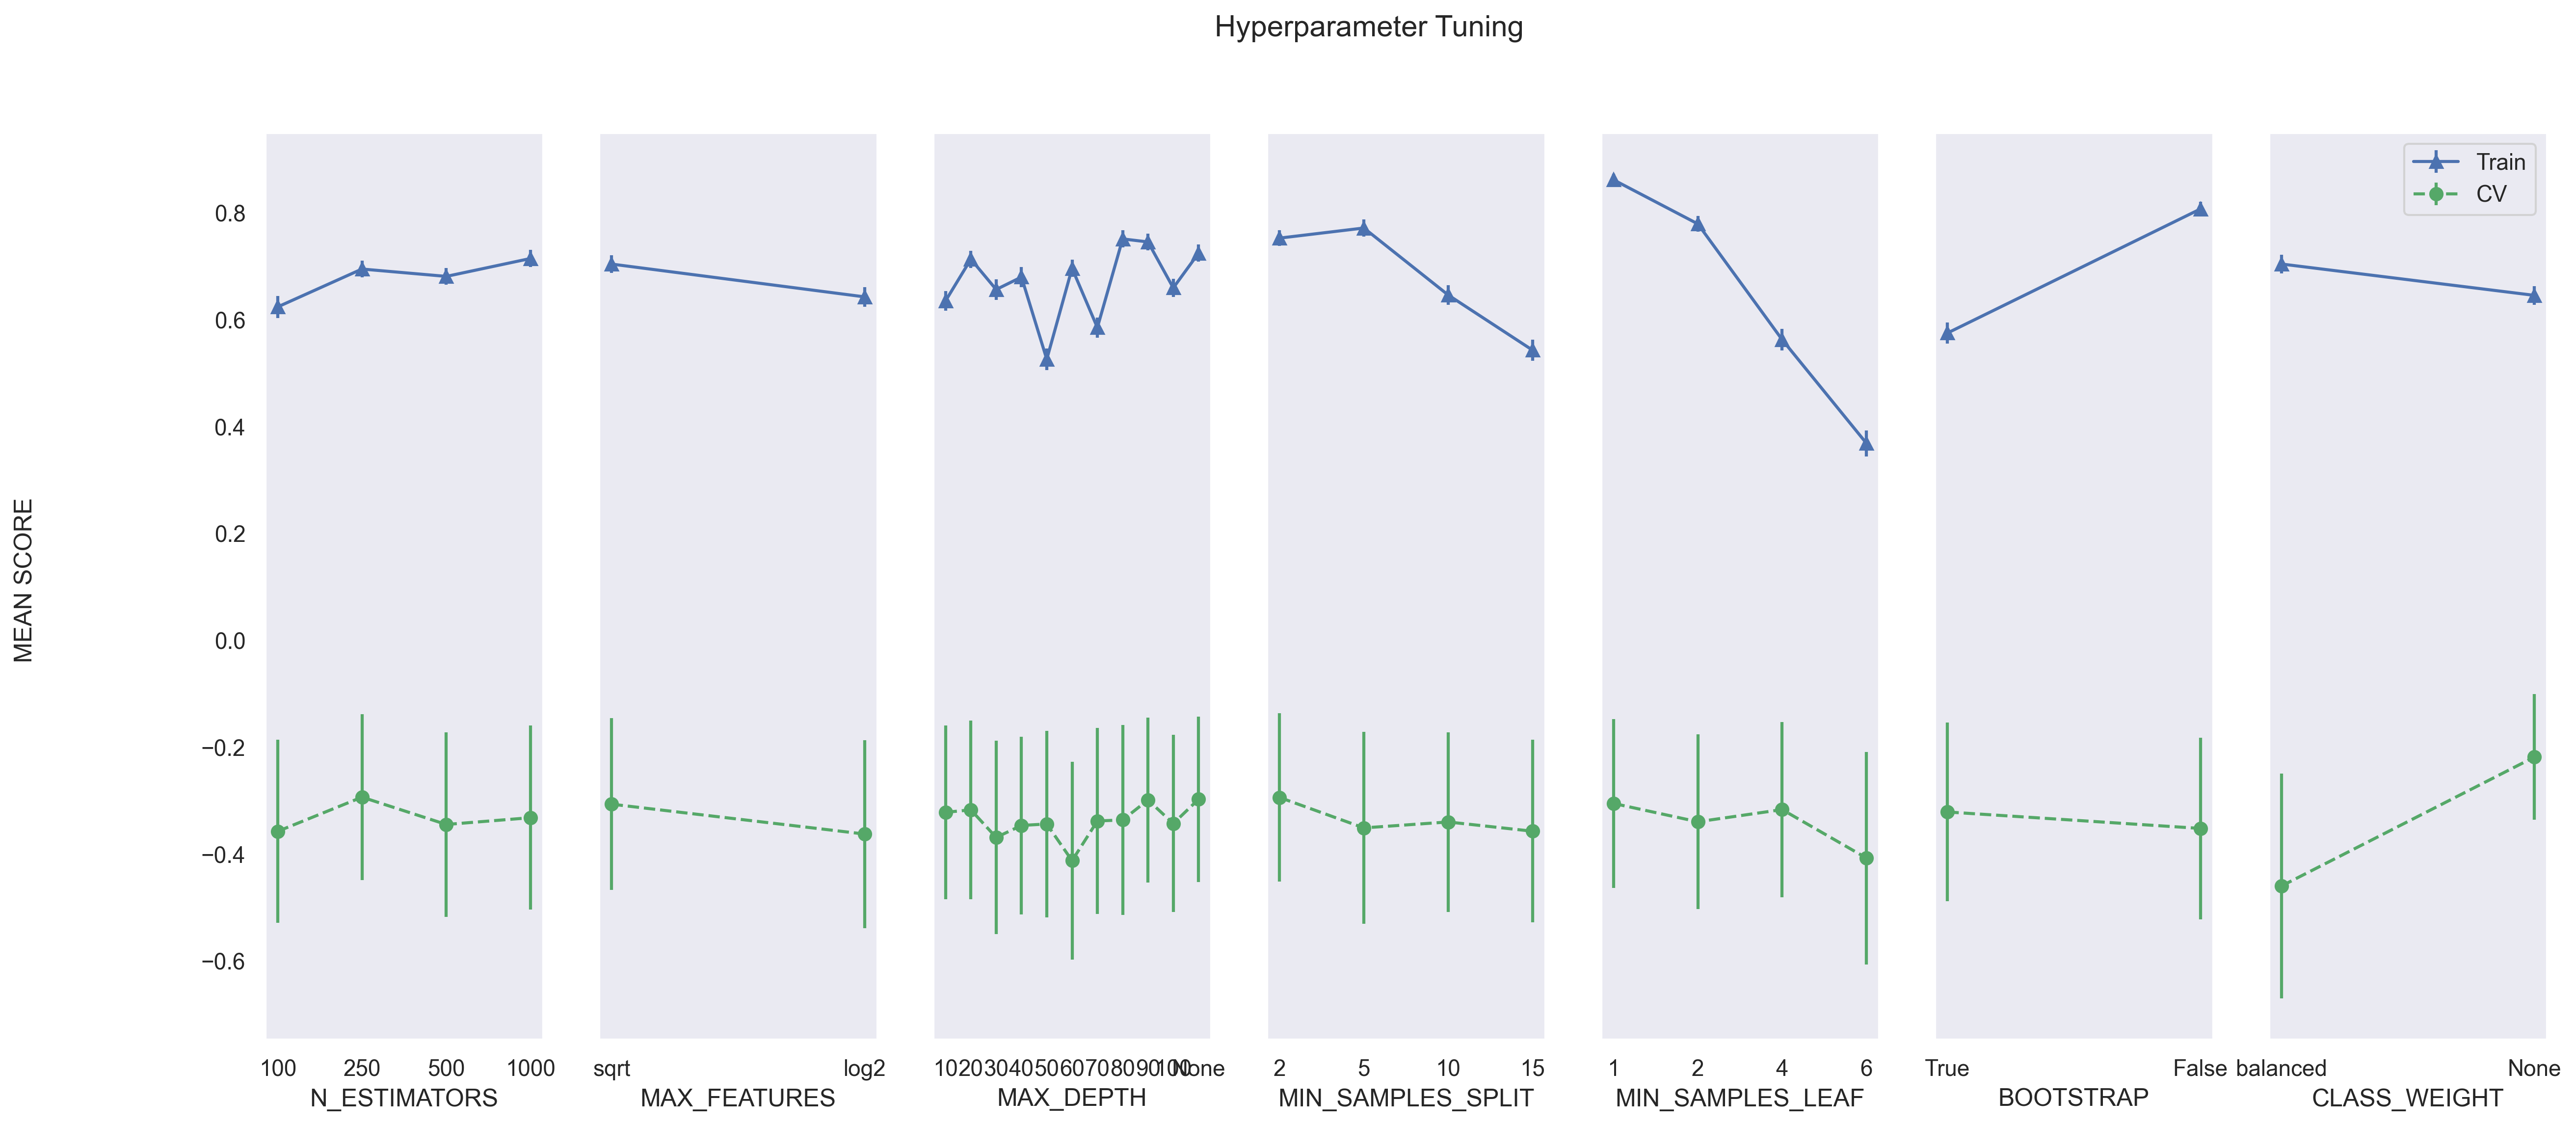

{'mean_fit_time': array([0.81952534, 0.39002595, 2.01584332, 0.51696694, 0.36524625,
       0.63531199, 0.47414937, 0.3763639 , 1.20630355, 0.51251211,
       0.40031202, 0.58047431, 0.19980497, 0.30105457, 1.68025796,
       0.55099707, 0.3542526 , 1.13941579, 2.13268201, 1.10833023,
       0.22142522, 2.39603953, 2.1990756 , 1.06268458, 0.50715585,
       0.67539613, 0.61126444, 3.11410091, 1.02951324, 1.08360579,
       0.22962191, 2.80593596, 1.29058104, 0.23469005, 0.62778862,
       0.95567293, 0.24850314, 0.24128554, 0.50315597, 2.83815594,
       0.23441133, 1.10200136, 0.20514362, 2.70642128, 0.23648963,
       0.27479942, 0.29130793, 0.62495179, 0.23438637, 1.11528442,
       2.15383532, 1.27338777, 0.22287147, 1.13489528, 2.13494744,
       1.69662802, 3.56991713, 0.25991976, 2.70634391, 2.34752274,
       2.46090348, 0.23991542, 0.27329731, 1.17181284, 0.65284202,
       2.16105821, 1.08601799, 1.30364082, 0.20411487, 2.01879263,
       0.25014951, 2.74554052, 0.22973108, 0

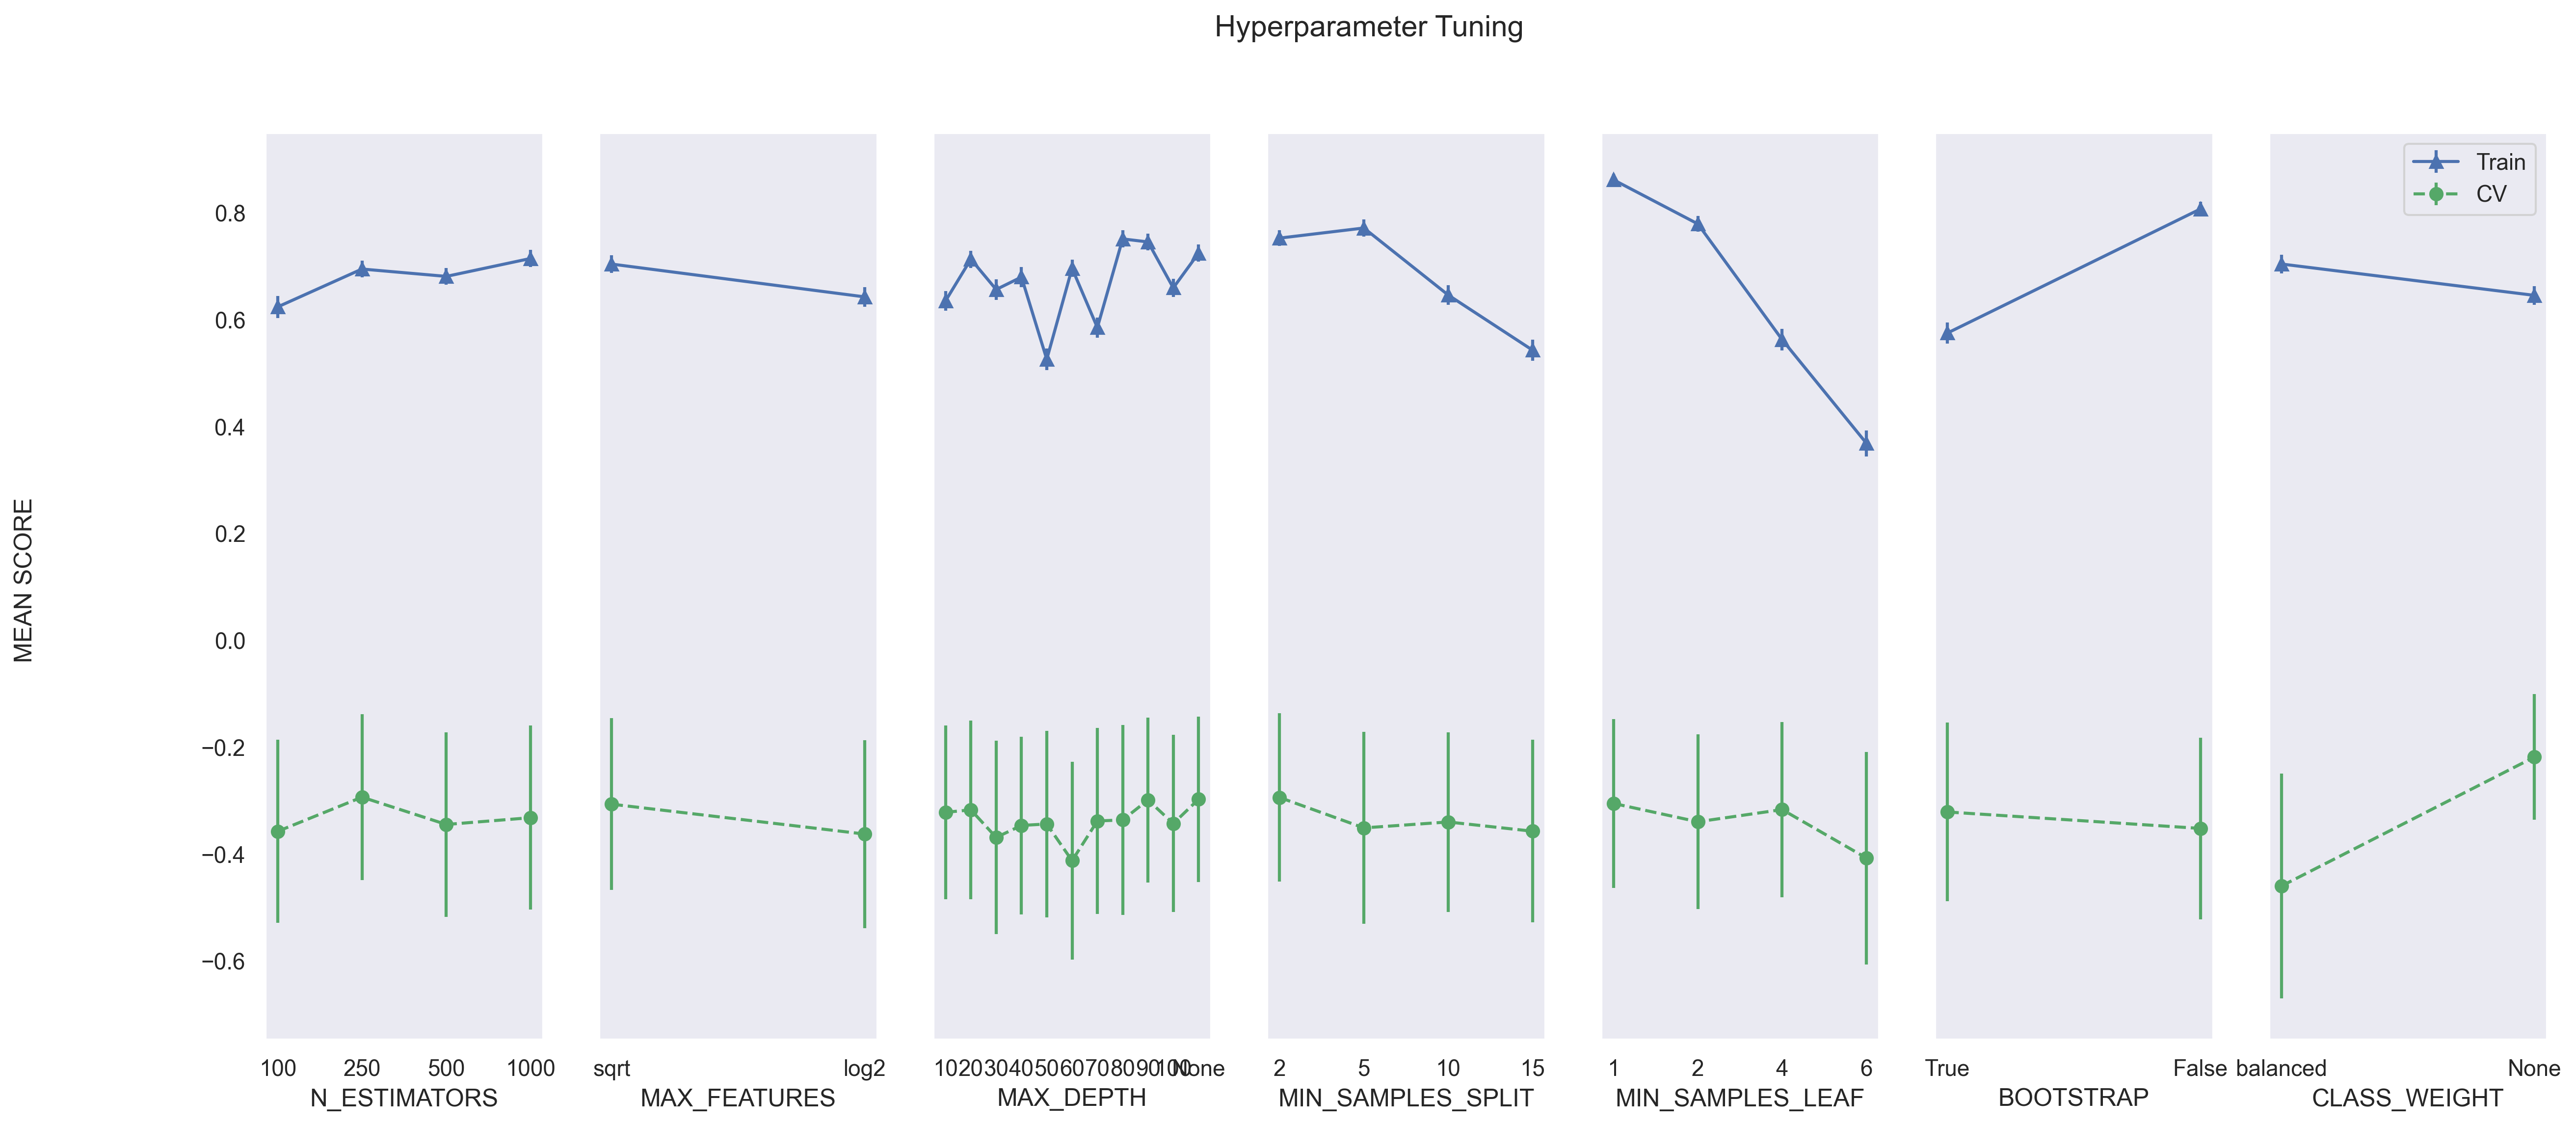

In [56]:
## Plot CV results
def plot_cv(tuner):
    results = tuner.cv_results_
    cv_params = tuner.param_distributions
    means_test = results['mean_test_score']
    stds_test = results['std_test_score']
    means_train = results['mean_train_score']
    stds_train = results['std_train_score']

    print(cv_params)
    fig, ax = plt.subplots(1, len(cv_params), sharex='none', sharey='all', figsize=(20,8), dpi=300)
    fig.suptitle('Hyperparameter Tuning')
    fig.text(0.04, 0.5, 'MEAN SCORE', va='center', rotation='vertical')

    scores = {}
    for i, (param, param_val) in enumerate(cv_params.items()):
        x, y1, e1, y2, e2 = [], [], [], [], []

        for v in param_val:
            mask_idx = results['param_'+param]==v
            v = str(v)

            m_train = np.mean(means_train[mask_idx])
            s_train = np.sqrt(np.mean(stds_train[mask_idx]**2))
            m_test = np.mean(means_test[mask_idx])    
            s_test = np.sqrt(np.mean(stds_test[mask_idx]**2))

            scores[param+'='+v+'_means_train'] = m_train
            scores[param+'='+v+'_stds_train'] = s_train    
            scores[param+'='+v+'_means_test'] = m_test
            scores[param+'='+v+'_stds_test'] = s_test
            print(param, "=", v, ":", m_test)

            x.append(v)
            y1.append(m_train)
            e1.append(s_train) 
            y2.append(m_test) 
            e2.append(s_test)

        ax[i].errorbar(x, y1, e1, linestyle='-', marker='^', label='Train')
        ax[i].errorbar(x, y2, e2, linestyle='--', marker='o', color='g', label='CV')
        ax[i].set_xlabel(param.upper())

    pp.pprint(scores)

    plt.legend()
    plt.show()

sns.set_style('dark')
plot_cv(tuner)
print(tuner.cv_results_)
plot_cv(saved_model)

In [57]:
## Evaluate model
print('Base model')
base_model = RandomForestRegressor(random_state=random_state)
base_model.fit(X_train, y_train)
base_accuracy = evaluate(base_model, X_test, y_test)

print('\nTuned model')
tuned_model = tuner.best_estimator_
tuned_accuracy = evaluate(tuned_model, X_test, y_test)

print('\nSaved model')
saved_accuracy = evaluate(saved_model.best_estimator_, X_test, y_test)

print('\nImprovement: {:0.4f}'.format(tuned_accuracy - base_accuracy))

Base model
Model Performance
MAE: 0.7398
MSE: 1.5459
RMSE: 1.2433
MRE: nan%
R2: 0.5564

Tuned model
Model Performance
MAE: 0.7368
MSE: 1.5519
RMSE: 1.2457
MRE: nan%
R2: 0.5609

Saved model
Model Performance
MAE: 0.7368
MSE: 1.5519
RMSE: 1.2457
MRE: nan%
R2: 0.5609

Improvement: 0.00
